In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

In [9]:
df = pd.read_csv("../data/data_market.csv", parse_dates=['Date'])
df.head()

,Date,^GSPC,^VIX
0,2010-01-04,1132.989990,20.040001
1,2010-01-05,1136.520020,19.350000
2,2010-01-06,1137.140015,19.160000
3,2010-01-07,1141.689941,19.059999
4,2010-01-08,1144.979980,18.129999


In [10]:
df.tail()

,Date,^GSPC,^VIX
4019,2025-12-24,6932.049805,13.47
4020,2025-12-26,6929.939941,13.60
4021,2025-12-29,6905.740234,14.20
4022,2025-12-30,6896.240234,14.33
4023,2025-12-31,6845.500000,14.95


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3522 entries, 0 to 3521
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3522 non-null   datetime64[us]
 1   ^GSPC   3522 non-null   float64       
 2   ^VIX    3522 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 82.7 KB


In [12]:
df.isnull().sum()

Date     0
^GSPC    0
^VIX     0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

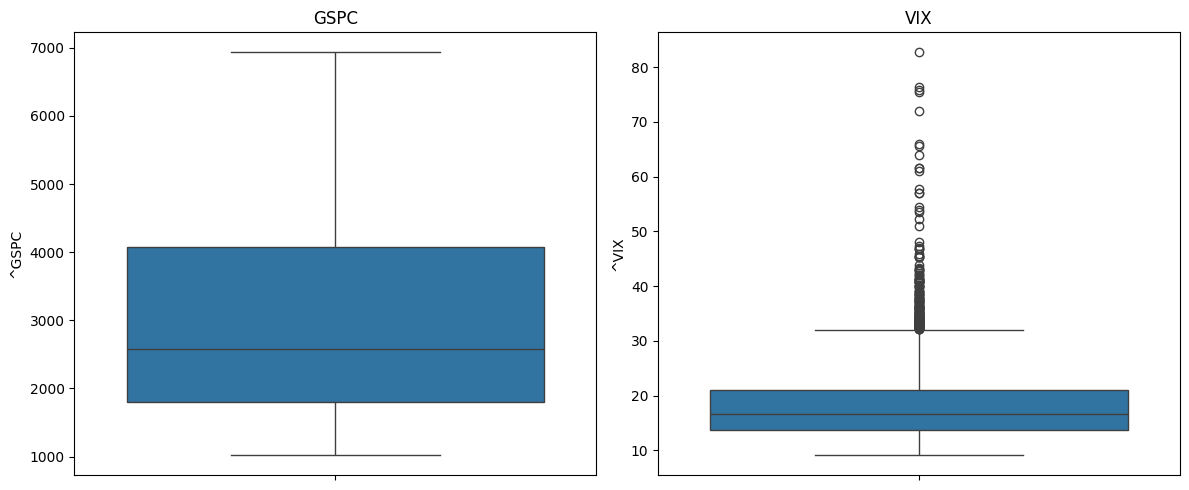

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['^GSPC'], ax=axes[0])
axes[0].set_title("GSPC")

sns.boxplot(y=df['^VIX'], ax=axes[1])
axes[1].set_title("VIX")
plt.tight_layout()
plt.show()

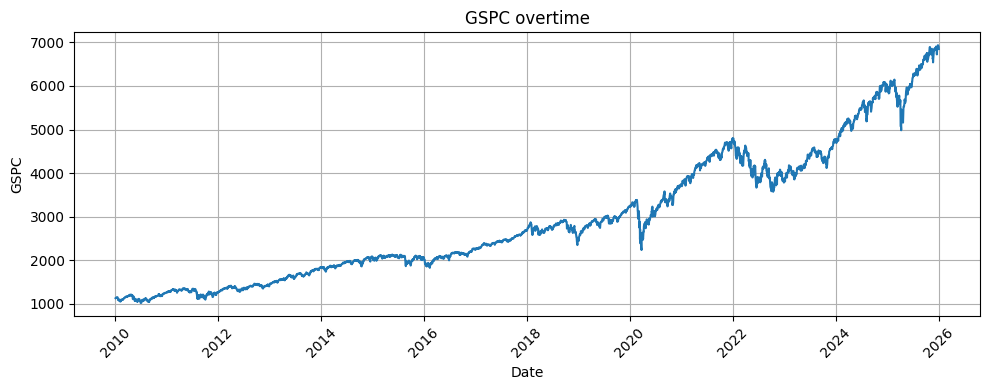

In [113]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='Date', y='^GSPC')
plt.title('GSPC overtime')
plt.xlabel('Date')
plt.ylabel('GSPC')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

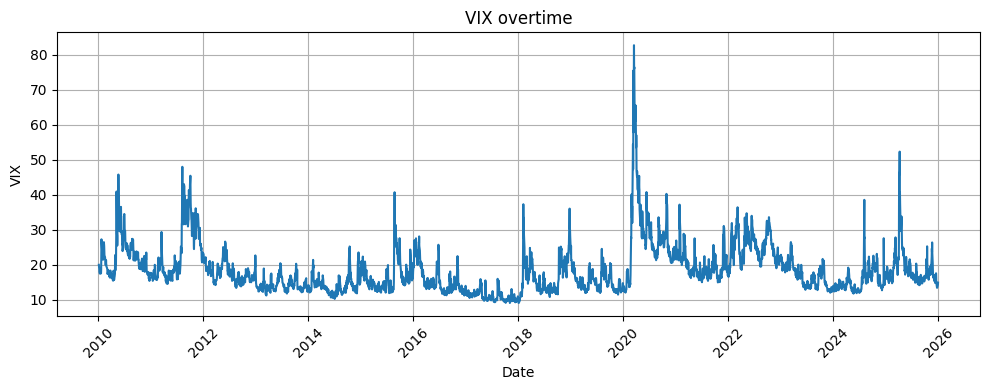

In [114]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='Date', y='^VIX')
plt.title('VIX overtime')
plt.xlabel('Date')
plt.ylabel('VIX')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

the S&P 500 (^GSPC) index has exhibited a strong, albeit non-linear, upward trajectory from 2010 through early 2026. This consistent growth reflects a long-term bullish market trend, punctuated by occasional corrections. Notably, the sharp, brief plunge around early 2020 corresponds with the initial shock of the COVID-19 pandemic, after which the index recovered rapidly and continued to achieve new all-time highs into 2025 and 2026.

Conversely, the Volatility Index (^VIX) plot demonstrates that market volatility generally remains within a lower, stable range (roughly between 10 and 20) during periods of steady growth in the S&P 500. However, the VIX is characterized by sudden, aggressive spikes that perfectly mirror moments of market distress or uncertainty. The most prominent spike occurs exactly in early 2020—aligning with the ^GSPC drop—where the VIX shoots above 80. These inverse dynamics highlight that rapid drawdowns in the equity market are heavily correlated with extreme surges in implied volatility, making the VIX a crucial indicator for identifying shifting market regimes.

In [23]:
df['gspc_log_ret'] = np.log(df['^GSPC'] / df['^GSPC'].shift(1))
df['vix_log_diff'] = np.log(df['^VIX']).diff()

In [25]:
df.head()

,Date,^GSPC,^VIX,gspc_log_ret,vix_log_diff
0,2010-01-04,1132.989990,20.040001,NaN,NaN
1,2010-01-05,1136.520020,19.350000,0.003111,-0.035038
2,2010-01-06,1137.140015,19.160000,0.000545,-0.009868
3,2010-01-07,1141.689941,19.059999,0.003993,-0.005233
4,2010-01-08,1144.979980,18.129999,0.002878,-0.050024


In [44]:
df_clean = df.dropna()
df_clean.head()

,Date,^GSPC,^VIX,gspc_log_ret,vix_log_diff
1,2010-01-05,1136.520020,19.350000,0.003111,-0.035038
2,2010-01-06,1137.140015,19.160000,0.000545,-0.009868
3,2010-01-07,1141.689941,19.059999,0.003993,-0.005233
4,2010-01-08,1144.979980,18.129999,0.002878,-0.050024
5,2010-01-11,1146.979980,17.549999,0.001745,-0.032514


In [45]:
X = df_clean[['gspc_log_ret', 'vix_log_diff']].values
X

array([[ 0.00311083, -0.03503788],
       [ 0.00054537, -0.00986767],
       [ 0.00399322, -0.00523289],
       ...,
       [-0.00349816,  0.04317213],
       [-0.00137661,  0.00911329],
       [-0.00738487,  0.04235605]], shape=(4023, 2))

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.24346276, -0.44765106],
       [ 0.00898091, -0.12540152],
       [ 0.32411247, -0.06606328],
       ...,
       [-0.36059628,  0.55365735],
       [-0.16668772,  0.11760822],
       [-0.71583925,  0.54320923]], shape=(4023, 2))

In [55]:
# covariance_type='full' in order to capture correlation between GSPC & VIX
model = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=22)

model.fit(X_scaled)

,n_components,2
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,22


In [56]:
regimes = model.predict(X_scaled)

df_clean['regime'] = regimes

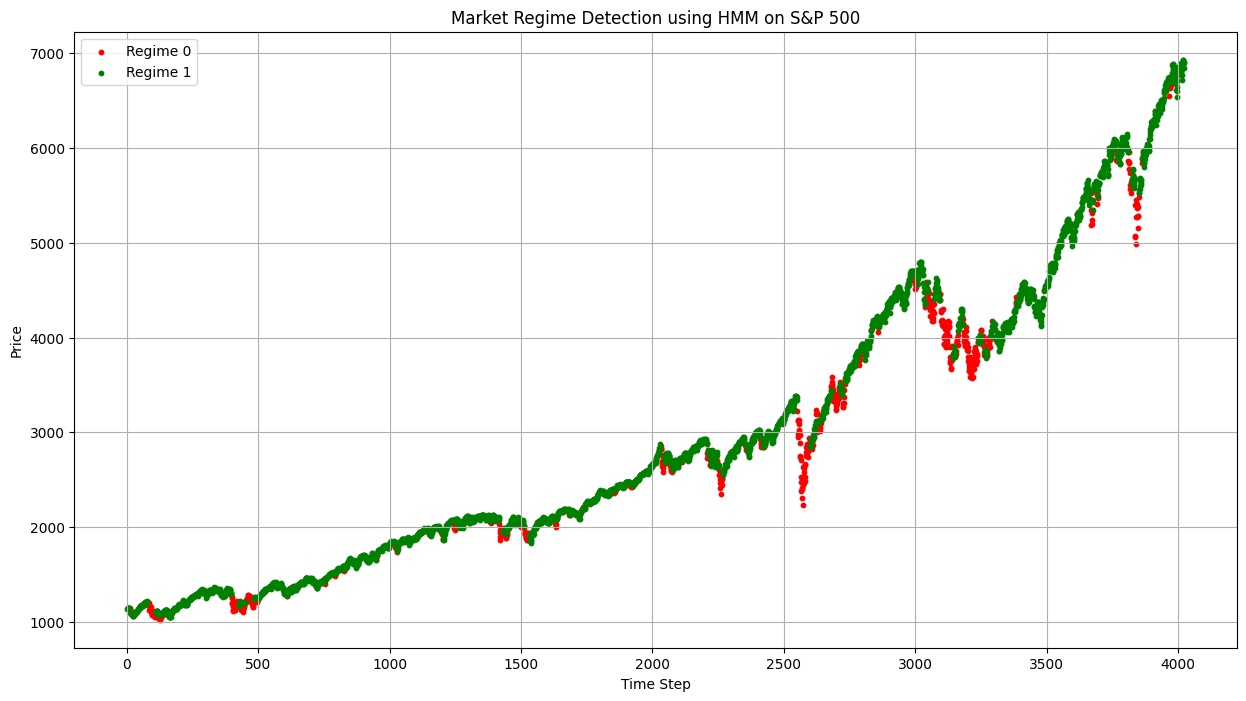

In [112]:
plt.figure(figsize=(15,8))

colors = ['red', 'green']
for i in range(model.n_components):
    mask = df_clean['regime'] == i
    plt.scatter(df_clean.index[mask], df_clean['^GSPC'][mask],
                label=f'Regime {i}', s=10, color=colors[i])
    
plt.title("Market Regime Detection using HMM on S&P 500")
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

a two-state Hidden Markov Model (HMM) applied to the S&P 500 (^GSPC) price data, successfully segmenting the market into distinct regimes. The green points, representing Regime 1, appear to predominantly capture extended periods of steady, upward price movement associated with a low-volatility "bull market" environment. Conversely, the red points, denoting Regime 0, are tightly clustered around localized price drops, sharp corrections, and periods of high volatility, such as the prominent crash in early 2020. This visual distinction confirms that the HMM effectively learned to differentiate between normal growth periods and turbulent market conditions based solely on the input features (log returns and VIX changes).

In [58]:
print("Mean of Every Component:")
means = scaler.inverse_transform(model.means_)
for i, m in enumerate(means):
    print(f"Regime {i}: GSPC LogRet = {m[0]:.5f}, VIX LogDiff = {m[1]:.5f}")

Mean of Every Component:
Regime 0: GSPC LogRet = -0.00173, VIX LogDiff = 0.01284
Regime 1: GSPC LogRet = 0.00097, VIX LogDiff = -0.00319


Regime 0 represents a "bear" market characterized by negative average daily returns (-0.173%) and increasing expected volatility, while Regime 1 represents a "bull" market with positive average returns (0.097%) and decreasing volatility.

In [ ]:
# Check Regime Persistence
print("Transition Matrix:")
print(model.transmat_)

Transition Matrix:
[[0.82943177 0.17056823]
 [0.04119202 0.95880798]]


The transition matrix indicates that both regimes are highly persistent, but Regime 1 (bull market) is significantly more stable with an almost 96% probability of remaining in that state the next day, whereas Regime 0 (bear market) has an ~83% probability of continuing and is more likely to transition back to a bull state.

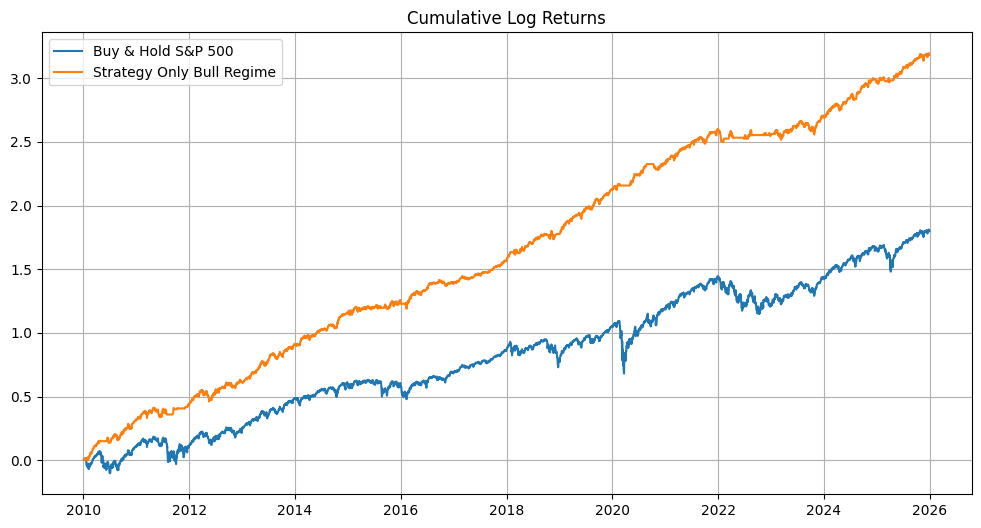

In [111]:
# Calculate Cumulative Return if only investing on regime 1
df_clean['only_bull_ret'] = np.where(df_clean['regime'] == 1, df_clean['gspc_log_ret'], 0)

plt.figure(figsize=(12,6))
plt.plot(df_clean['Date'], df_clean['gspc_log_ret'].cumsum(), label='Buy & Hold S&P 500')
plt.plot(df_clean['Date'], df_clean['only_bull_ret'].cumsum(), label='Strategy Only Bull Regime')
plt.title('Cumulative Log Returns')
plt.legend()
plt.grid()
plt.show()

The plot shows that a “buy & hold” strategy steadily accumulates positive log returns over time but experiences noticeable drawdowns during market stress periods, while the “only bull regime” strategy produces a smoother and consistently higher cumulative return trajectory by effectively sitting out the down‑state periods identified by the HMM, suggesting that regime filtering can meaningfully improve long‑term return performance in this dataset.

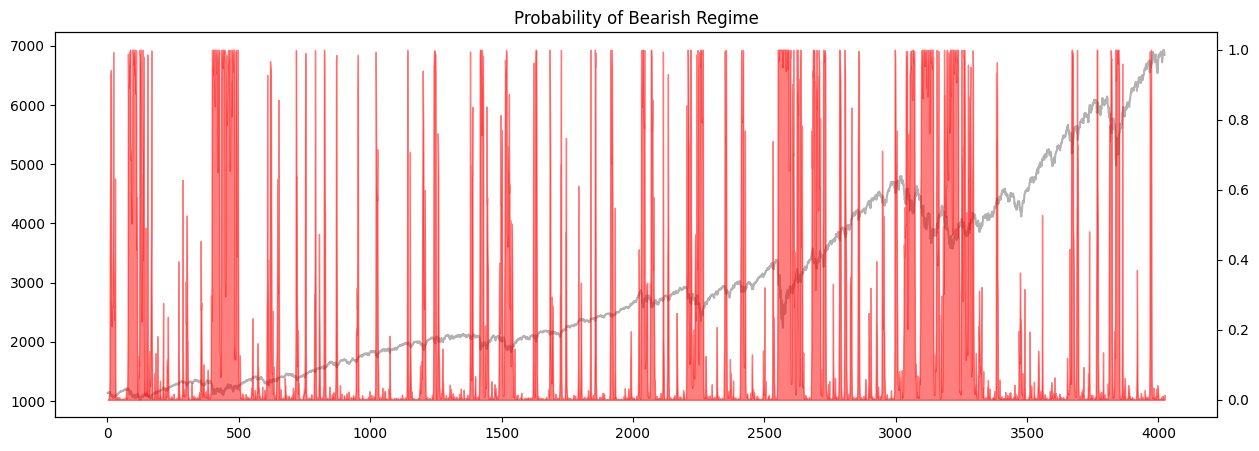

In [70]:
# Check Matrix Probability (Posterior)
probs = model.predict_proba(X_scaled)
df_clean['prob_regime_0'] = probs[:, 0]
df_clean['prob_regime_1'] = probs[:, 1]

# Plot Bearish probability with GSPC
fig, ax1 = plt.subplots(figsize=(15,5))
ax1.plot(df_clean['^GSPC'], color='black', alpha=0.3)
ax2 = ax1.twinx()
ax2.fill_between(df_clean.index, 0, df_clean['prob_regime_0'], color='red', alpha=0.5)
plt.title('Probability of Bearish Regime')
plt.show()

Periods where the red fill spikes toward 1 correspond to times when the HMM strongly believes the market is in a “bearish” state, and these spikes typically align with visible price drops or heightened turbulence in the S&P 500, indicating the model’s ability to flag heightened downside risk periods.

# Out-of-Sample Test (Walk-Forward)

In [73]:
df_oos = df.copy()
df_oos.head()

,Date,^GSPC,^VIX,gspc_log_ret,vix_log_diff
0,2010-01-04,1132.989990,20.040001,NaN,NaN
1,2010-01-05,1136.520020,19.350000,0.003111,-0.035038
2,2010-01-06,1137.140015,19.160000,0.000545,-0.009868
3,2010-01-07,1141.689941,19.059999,0.003993,-0.005233
4,2010-01-08,1144.979980,18.129999,0.002878,-0.050024


In [74]:
df_oos = df_oos.dropna().reset_index(drop=True)
df_oos.head()

,Date,^GSPC,^VIX,gspc_log_ret,vix_log_diff
0,2010-01-05,1136.520020,19.350000,0.003111,-0.035038
1,2010-01-06,1137.140015,19.160000,0.000545,-0.009868
2,2010-01-07,1141.689941,19.059999,0.003993,-0.005233
3,2010-01-08,1144.979980,18.129999,0.002878,-0.050024
4,2010-01-11,1146.979980,17.549999,0.001745,-0.032514


In [100]:
train_mask = (df_oos["Date"] >= "2010-01-05") & (df_oos["Date"] <= "2024-12-31")
test_mask = (df_oos["Date"] >= "2025-01-01") & (df_oos["Date"] <= "2025-12-31")

In [101]:
train_df = df_oos.loc[train_mask]
test_df = df_oos.loc[test_mask]

In [102]:
feat_cols = ["gspc_log_ret", "vix_log_diff"]
X_train = train_df[feat_cols].values
X_test = test_df[feat_cols].values

In [103]:
scaler_oos = StandardScaler()
X_train_scaled = scaler_oos.fit_transform(X_train)
X_test_scaled = scaler_oos.fit_transform(X_test)

In [104]:
hmm_oos = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=22)
hmm_oos.fit(X_train_scaled)

,n_components,2
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,22


In [106]:
test_df["regime_raw"] = hmm_oos.predict(X_test_scaled)
proba_test = hmm_oos.predict_proba(X_test_scaled)
test_df["prob_regime_0"] = proba_test[:, 0]
test_df["prob_regime_1"] = proba_test[:, 1]

In [116]:
test_df.head()

,Date,^GSPC,^VIX,gspc_log_ret,vix_log_diff,regime_raw,prob_regime_0,prob_regime_1,ret_only_bull
3773,2025-01-02,5868.549805,17.930000,-0.002226,0.032883,1,1.690827e-53,1.000000,-0.002226
3774,2025-01-03,5942.470215,16.129999,0.012517,-0.105794,1,4.100932e-03,0.995899,0.012517
3775,2025-01-06,5975.379883,16.040001,0.005523,-0.005595,1,3.479163e-03,0.996521,0.005523
3776,2025-01-07,5909.029785,17.820000,-0.011166,0.105236,1,7.449720e-03,0.992550,-0.011166
3777,2025-01-08,5918.250000,17.700001,0.001559,-0.006757,1,4.302008e-03,0.995698,0.001559


In [107]:
oos_stats = test_df.groupby("regime_raw")["gspc_log_ret"].agg(["mean", "std", "count"])
print("OOS 2025 stats by predicted regime:")
print(oos_stats)

OOS 2025 stats by predicted regime:
                mean       std  count
regime_raw                           
0          -0.001295  0.029291     27
1           0.000837  0.007334    223


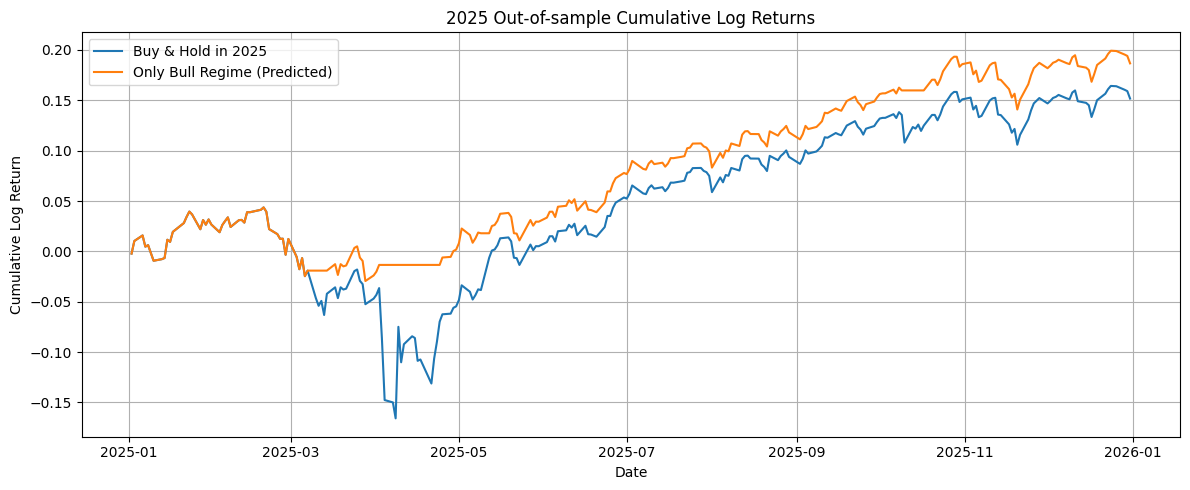

In [110]:
test_df["ret_only_bull"] = np.where(test_df["regime_raw"] == 1, test_df["gspc_log_ret"], 0)

plt.figure(figsize=(12, 5))
plt.plot(test_df["Date"], test_df["gspc_log_ret"].cumsum(), label="Buy & Hold in 2025")
plt.plot(test_df["Date"], test_df["ret_only_bull"].cumsum(), label="Only Bull Regime (Predicted)")
plt.title("2025 Out-of-sample Cumulative Log Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Around March and April, the market experienced a sharp drawdown that significantly impacted the Buy & Hold portfolio. However, the predictive model successfully identified this bearish phase, allowing the "Only Bull" strategy to flatten its curve and avoid severe losses. Because it sidestepped this major downturn, the regime-filtered strategy maintained a persistent performance advantage throughout the subsequent recovery, ultimately achieving a noticeably higher cumulative return with reduced downside risk by the end of the year.